#Multiple Linear Regression uses multiple features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/content/economic_index.csv')
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [4]:
#Drop unnecessary cols

df.drop(['Unnamed: 0','year','month'], axis=1, inplace=True)
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [5]:
#Check null values
df.isnull().sum()

,0
interest_rate,0
unemployment_rate,0
index_price,0


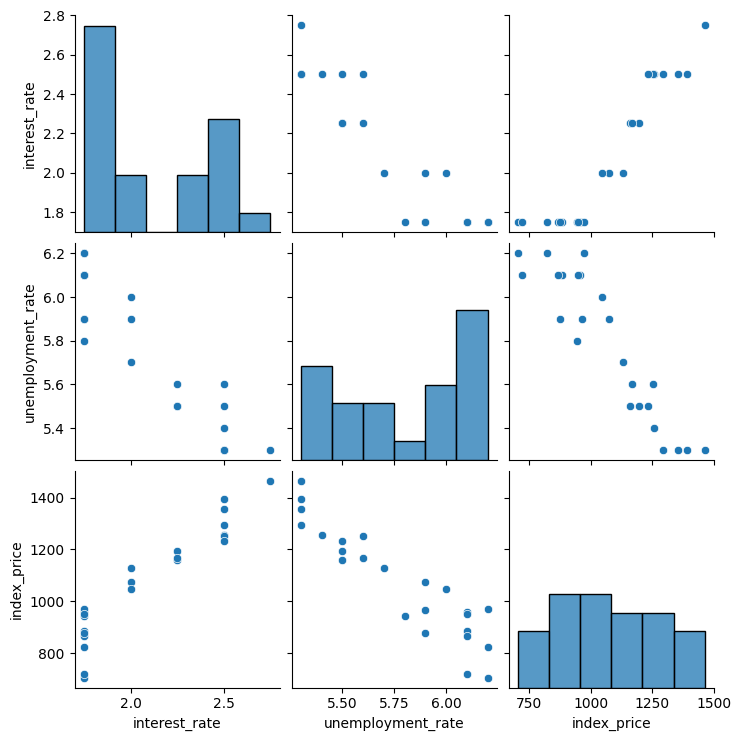

In [6]:
#Visualization

import seaborn as sns
sns.pairplot(df)

In [7]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


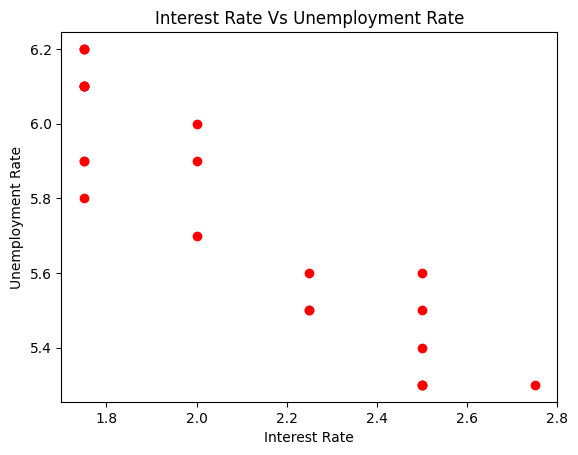

In [8]:
plt.scatter(df['interest_rate'],df['unemployment_rate'],color='r')
plt.xlabel('Interest Rate')
plt.ylabel('Unemployment Rate')
plt.title('Interest Rate Vs Unemployment Rate')
plt.show()

In [9]:
X = df[['interest_rate','unemployment_rate']]
y = df.iloc[:,-1]     #taking the last col and inserting into y

In [13]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [10]:
y.head()

,index_price
0,1464
1,1394
2,1357
3,1293
4,1256


In [11]:
#Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

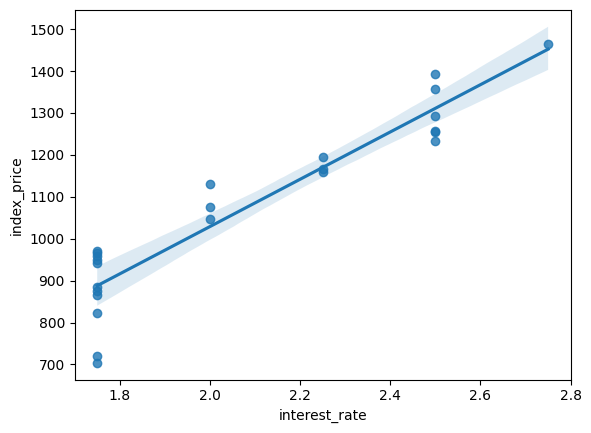

In [15]:
import seaborn as sns
sns.regplot(x=df['interest_rate'],y=df['index_price'])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

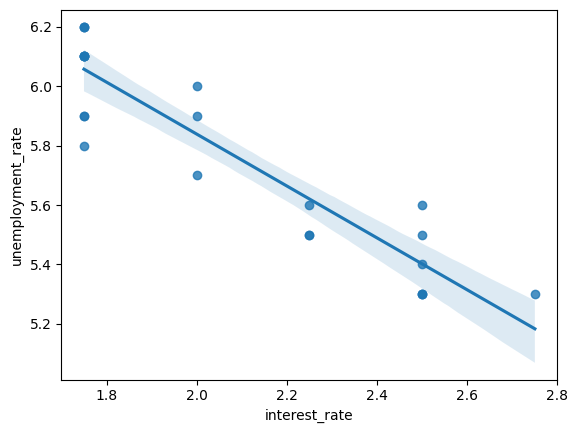

In [16]:
sns.regplot(x=df['interest_rate'],y=df['unemployment_rate'])

<Axes: xlabel='index_price', ylabel='unemployment_rate'>

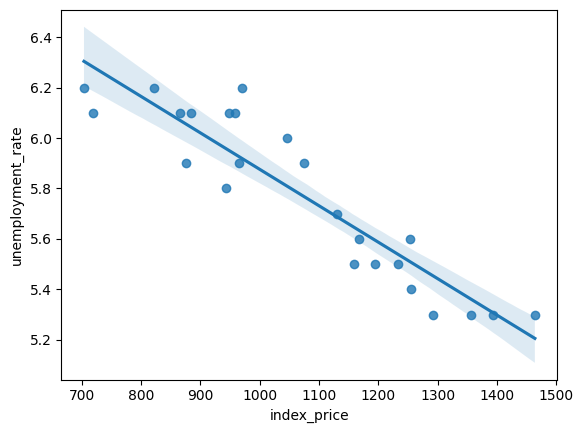

In [17]:
sns.regplot(x=df['index_price'],y=df['unemployment_rate'])

In [18]:
#Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
X_test

array([[ 0.57346234, -0.8615569 ],
       [-0.90115511,  1.30956648],
       [ 2.0480798 , -1.48187786],
       [-0.90115511,  0.999406  ],
       [-0.16384638,  0.37908503],
       [ 0.57346234, -0.55139641]])

In [20]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train,y_train)

LinearRegression()

In [39]:
print("Coefficient or Slope:",regression.coef_)
print("Intercept:",regression.intercept_)

Coefficient or Slope: [  88.27275507 -116.25716066]
Intercept: 1053.4444444444443


In [23]:
#Cross Validation

from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(regression, X_train, y_train, scoring = 'neg_mean_squared_error',cv = 3)

In [24]:
#gives 3 negative mse as scoring is -mse and cross validation=3
#more the mse's r near 0 more better it is
validation_score

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [26]:
print(np.mean(validation_score))

-5914.828180162386


In [27]:
#Prediction
y_pred = regression.predict(X_test)
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [28]:
#Performance metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

5793.762887712569
59.935781523235484
76.11677139574805


In [29]:
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
print(score)

0.8278978091457145


In [30]:
adj_r2 = 1 - ((1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))
print(adj_r2)

0.7131630152428576


#Assumptions

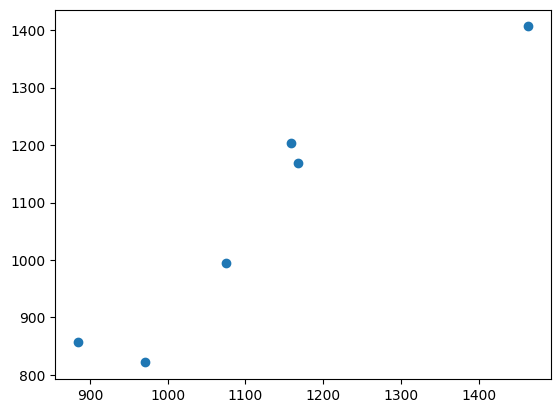

In [31]:
plt.scatter(y_test, y_pred)
#if a linear relationship comes then prediction is correct

In [32]:
residuals = y_test - y_pred   #errors
print(residuals)

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64


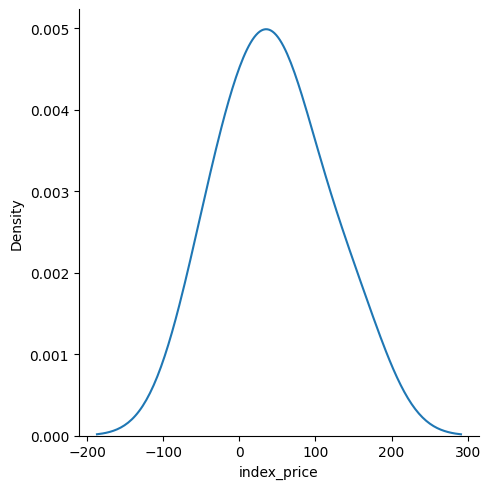

In [36]:
#Plot residuals
sns.displot(residuals,kind = 'kde')       #Kernal Density Estimator(kde)

#displot = Distribution plot

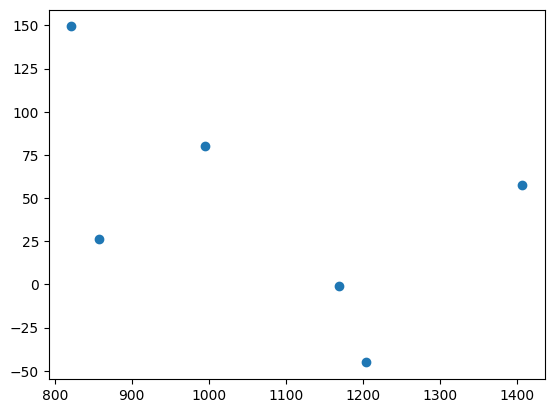

In [37]:
#Scatter plot with respect to prediction and residuals
plt.scatter(y_pred, residuals)

In [38]:
#OLS Linear Regression

import statsmodels.api as sm
model = sm.OLS(y_train, X_train).fit()      #model is fit using OLS library
prediction = model.predict(X_test)
print(prediction)

[ 150.78325954 -231.79392541  353.06855924 -195.73554836  -58.53452146
  114.72488249]


In [40]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Wed, 14 May 2025   Prob (F-statistic):                       0.754
Time:                        06:00:55   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)
